# E5: Placebic NLE Control

**Research question:** Is the NLE effect in E1 driven by the *content* of the NLE, or just by the *presence of text* (information overload)?

## Design

Replicates E1's closeness task with a 3-condition design. All conditions include features + SHAP + metrics (matching E1's X+T baseline).

| Condition | Features | SHAP (X) | Metrics (T) | NLE |
|-----------|:--:|:--:|:--:|:--:|
| Baseline | ✓ | ✓ | ✓ | None |
| Real_NLE | ✓ | ✓ | ✓ | Correct NLE for THIS instance |
| Placebo_NLE | ✓ | ✓ | ✓ | NLE from a DIFFERENT instance |

**2×2 generator×judge design:** For NLE conditions (Real_NLE, Placebo_NLE), both GPT-4o and DeepSeek-R1 NLEs are evaluated by both judges (4 combinations). Baseline has no generator dimension — just 2 judges.

## Key comparisons

1. `Baseline` vs `Real_NLE`: Replicates E1's X+T vs E+X+T contrast
2. `Baseline` vs `Placebo_NLE`: Is extra text alone harmful?
3. `Real_NLE` vs `Placebo_NLE`: Does specific NLE content matter?

## Judgment count

- Baseline: N × 2 judges
- Real_NLE: N × 2 generators × 2 judges
- Placebo_NLE: N × 2 generators × 2 judges
- **Pilot (N=15):** 15×2 + 15×4 + 15×4 = 30 + 60 + 60 = **150**
- **Full (N=60):** 60×2 + 60×4 + 60×4 = 120 + 240 + 240 = **600**

## Interpretation guide

| Pattern | Interpretation |
|---------|---------------|
| `Baseline` >> `Real_NLE` ≈ `Placebo_NLE` | Information overload: any extra text hurts |
| `Baseline` >> `Real_NLE` >> `Placebo_NLE` | NLE content actively misleads; generic text less harmful |
| `Baseline` ≈ `Placebo_NLE` >> `Real_NLE` | Real NLE uniquely misleads (content-specific harm) |

## Statistical plan

- **Primary:** Accuracy by condition, pairwise comparisons with Bonferroni correction (3 pairs, α=0.017)
- **Secondary:** Confidence analysis — does any NLE (real or placebo) increase confidence?
- **95% CI:** Wilson interval
- **Pilot (N=15) → effect size → power check → Full (N=60)**

## 0. Setup

In [1]:
import os
import sys
import asyncio
import json
import re
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm
import matplotlib.pyplot as plt

import utils

# ── Toggle: pilot vs full ──────────────────────────────────────────
PILOT_MODE = False   # Set False for full experiment
N = 15 if PILOT_MODE else 60
RANDOM_SEED = 42
# ───────────────────────────────────────────────────────────────────

# Override from run_all.py script
if os.environ.get('EXPERIMENT_N'):
    N = int(os.environ['EXPERIMENT_N'])
    PILOT_MODE = N < 60

RESULTS_DIR = utils.RESULTS_DIR / 'E5'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# 3 conditions: baseline (no NLE), real NLE, placebo NLE (from different instance)
# All conditions include features + SHAP + metrics (matching E1's X+T baseline)
CONDITIONS = [
    {'name': 'Baseline',    'nle': False, 'placebo': False, 'xai': True, 'metrics': True},
    {'name': 'Real_NLE',    'nle': True,  'placebo': False, 'xai': True, 'metrics': True},
    {'name': 'Placebo_NLE', 'nle': True,  'placebo': True,  'xai': True, 'metrics': True},
]

VALID_BUCKETS = {'small', 'medium', 'large', 'very_large'}

mode_str = f'PILOT (N={N})' if PILOT_MODE else f'FULL (N={N})'
print(f'E5 Placebic NLE Control — {mode_str}')
print(f'Conditions: {[c["name"] for c in CONDITIONS]}')

E5 Placebic NLE Control — FULL (N=60)
Conditions: ['Baseline', 'Real_NLE', 'Placebo_NLE']


## 1. Load data

In [2]:
# Load test instances with SHAP values
model = utils.load_xgb_model()
test_df = utils.build_test_with_shap(model)
test_df['error_bucket'] = test_df['pct_error'].apply(utils.pct_error_to_bucket)

# Load NLE cache (120 rows: 60 × 2 generators)
nle_cache = utils.load_nle_cache()

print(f'Test instances: {len(test_df)}')
print(f'NLE cache: {len(nle_cache)} rows ({nle_cache["generator"].value_counts().to_dict()})')
print(f'Error bucket distribution:')
print(test_df['error_bucket'].value_counts())

# Sample N instances (stratified by error bucket) — same as E1
if N < len(test_df):
    sampled_indices = []
    for bucket, group in test_df.groupby('error_bucket'):
        n_from_bucket = max(1, round(N * len(group) / len(test_df)))
        sampled_indices.extend(group.sample(min(len(group), n_from_bucket),
                                            random_state=RANDOM_SEED).index.tolist())
    if len(sampled_indices) < N:
        remaining = [i for i in test_df.index if i not in sampled_indices]
        extra = np.random.default_rng(RANDOM_SEED).choice(remaining, size=N - len(sampled_indices), replace=False)
        sampled_indices.extend(extra.tolist())
    sampled_indices = sampled_indices[:N]
    sample_df = test_df.loc[sampled_indices].copy()
else:
    sample_df = test_df.copy()

# orig_idx = original test set index = RowPos in nle_cache
sample_df['orig_idx'] = sample_df.index
sample_df = sample_df.reset_index(drop=True)

print(f'\nUsing {len(sample_df)} instances')
print('Sample bucket distribution:', sample_df['error_bucket'].value_counts().to_dict())
print('orig_idx values (RowPos):', sorted(sample_df['orig_idx'].tolist()))

Test instances: 60
NLE cache: 120 rows ({'gpt': 60, 'deepseek': 60})
Error bucket distribution:
error_bucket
medium        29
large         16
small         12
very_large     3
Name: count, dtype: int64

Using 60 instances
Sample bucket distribution: {'medium': 29, 'large': 16, 'small': 12, 'very_large': 3}
orig_idx values (RowPos): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]


## 2. Build placebo NLE assignments

For each instance and each generator, assign a NLE from a DIFFERENT instance (derangement — no instance gets its own NLE).

In [3]:
# Build NLE lookup: {(RowPos, generator) -> Explanation}
nle_lookup = {}
for _, nle_row in nle_cache.iterrows():
    nle_lookup[(int(nle_row['RowPos']), nle_row['generator'])] = nle_row['Explanation']

# Build derangement on ALL 60 instances (fixed by seed, reusable for pilot and full)
rng = np.random.default_rng(RANDOM_SEED)
all_indices = list(range(len(test_df)))  # 0-59

def make_derangement(n, rng):
    """Create a random derangement (no fixed points) of [0, 1, ..., n-1]."""
    perm = list(range(n))
    rng.shuffle(perm)
    # Fix any fixed points
    for i in range(n):
        if perm[i] == i:
            j = (i + 1) % n
            perm[i], perm[j] = perm[j], perm[i]
    return perm

# One derangement per generator
placebo_map = {}
for gen in ['gpt', 'deepseek']:
    derangement = make_derangement(len(test_df), np.random.default_rng(RANDOM_SEED + hash(gen) % 1000))
    for orig_idx in all_indices:
        placebo_source = derangement[orig_idx]
        placebo_nle = nle_lookup.get((placebo_source, gen), '')
        placebo_map[(orig_idx, gen)] = {
            'source_idx': placebo_source,
            'nle': placebo_nle,
        }

# Verify: no instance maps to itself
for gen in ['gpt', 'deepseek']:
    self_matches = sum(1 for idx in all_indices if placebo_map[(idx, gen)]['source_idx'] == idx)
    print(f'{gen}: self-matches = {self_matches} (should be 0)')

# Preview
orig_0 = int(sample_df.iloc[0]['orig_idx'])
print(f'\nInstance {orig_0}:')
print(f'  Real GPT NLE (first 100 chars): {nle_lookup.get((orig_0, "gpt"), "")[:100]}...')
print(f'  Placebo GPT NLE from instance {placebo_map[(orig_0, "gpt")]["source_idx"]} (first 100 chars): {placebo_map[(orig_0, "gpt")]["nle"][:100]}...')

gpt: self-matches = 0 (should be 0)
deepseek: self-matches = 0 (should be 0)

Instance 0:
  Real GPT NLE (first 100 chars): - The model predicted that the next week's energy consumption will be 168.76 kWh. This prediction wa...
  Placebo GPT NLE from instance 13 (first 100 chars): - **Reason for Prediction**: The forecast of 222.85 kWh relies heavily on recent past energy usage t...


## 3. Build judge prompts

In [4]:
# Same JUDGE_SYSTEM as E1 (identical task)
JUDGE_SYSTEM = """You are evaluating a machine learning model's prediction accuracy for a time series forecasting task.
You have limited background in machine learning and statistics — you understand basic concepts but are not an expert.

Your task: Based on all the information provided, assess how large the prediction error is likely to be. Carefully evaluate the features, model context, and any additional information given to form your judgment.

Important: Think carefully about each specific instance. Consider all the details provided — feature values, patterns, and any explanations. Do not default to a "safe" middle-ground answer. The prediction has a specific error magnitude; use the evidence to determine what it is.

Evaluation steps (think through each before giving your final answer):
1. Examine the features — consider the lag values, the time of year (season in France), holidays, and whether the prediction seems reasonable given this context
2. Compare the prediction to recent lag values — does it follow the recent trend?
3. If model performance metrics are provided, use them to estimate a typical error range
4. If SHAP values are provided, consider whether each feature's contribution makes sense given the feature values and context
5. If a natural language explanation is provided, you can use it to better understand the model's reasoning
6. Weigh all available evidence to determine the most likely error magnitude

Error bucket definitions (based on absolute percentage error, regardless of whether the model over- or under-predicts):
- small: [0%, 5%) — absolute error less than 5%
- medium: [5%, 15%) — absolute error from 5% up to but not including 15%
- large: [15%, 30%) — absolute error from 15% up to but not including 30%
- very_large: [30%, +inf) — absolute error 30% or more

Confidence scale:
- 1 = Very uncertain about my assessment
- 2 = Somewhat uncertain
- 3 = Moderately confident
- 4 = Fairly confident
- 5 = Very certain about my assessment

You must respond with EXACTLY this JSON format and nothing else:
{
  "error_bucket": "<one of: small, medium, large, very_large>",
  "confidence": <integer from 1 to 5>,
  "reasoning": "<one sentence explaining your choice>"
}"""

DOMAIN_CONTEXT = """The following is about time series data with a single-step ahead prediction, where the model predicts the next value in the time series based on previous observations.
Data Domain: Energy Consumption
Dataset Description:
- The dataset contains 2,075,259 measurements from a house in Sceaux, France (near Paris), Dec 2006–Nov 2010.
- Recorded at one-minute resolution, then resampled weekly.
- Lag_1..Lag_7 (previous 7 weeks of consumption in kWh), ISO week number and number of public holidays per week were added as features.
- Target: weekly electricity consumption (kWh)."""


def build_prompt(row: pd.Series, condition: dict, nle_text: str = '') -> str:
    """Build the judge prompt — same structure as E1's build_prompt."""
    parts = [DOMAIN_CONTEXT, '']

    parts.append(f'Model Used: XGBRegressor')

    # Metrics (always included in E5 — all conditions are X+T based)
    if condition['metrics']:
        parts.append(f'Model Performance:')
        parts.append(f'  - MAE: {utils.XGB_PERF["MAE"]:.3f}')
        parts.append(f'  - RMSE: {utils.XGB_PERF["RMSE"]:.3f}')
        parts.append(f'  - R²: {utils.XGB_PERF["R2"]:.3f}')

    parts.append(f'')
    parts.append(f'Prediction: {row["prediction"]:.2f}')
    parts.append(f'')
    parts.append(f'Instance Features or Context:')
    for f in utils.FEATURES:
        parts.append(f'{f}: {row[f]}')

    # SHAP values (always included in E5)
    if condition['xai']:
        parts.append(f'')
        parts.append(f'SHAP values:')
        shap_pairs = [(f, row[f'shap_{f}']) for f in utils.FEATURES]
        shap_pairs.sort(key=lambda x: abs(x[1]), reverse=True)
        for feat, val in shap_pairs:
            parts.append(f'{feat}: {val:+.3f}')
        parts.append(f'The expected/base value for SHAP: {row["shap_base_value"]:.3f}')

    # NLE (real or placebo)
    if condition['nle'] and nle_text:
        parts.append(f'')
        parts.append(f'Natural language explanation of this prediction:')
        parts.append(nle_text)

    parts.append(f'')
    parts.append(f'Based on all the information above, classify this prediction\'s likely error bucket.')

    return '\n'.join(parts)


# Preview prompts
row0 = sample_df.iloc[0]
orig_idx_0 = int(row0['orig_idx'])

print('=== Baseline condition ===')
print(build_prompt(row0, CONDITIONS[0]))
print()
print('=== Real_NLE condition ===')
real_nle = nle_lookup.get((orig_idx_0, 'gpt'), '')
print(build_prompt(row0, CONDITIONS[1], real_nle))
print()
print('=== Placebo_NLE condition ===')
placebo_nle = placebo_map[(orig_idx_0, 'gpt')]['nle']
print(f'(Placebo from instance {placebo_map[(orig_idx_0, "gpt")]["source_idx"]})')
print(build_prompt(row0, CONDITIONS[2], placebo_nle))

=== Baseline condition ===
The following is about time series data with a single-step ahead prediction, where the model predicts the next value in the time series based on previous observations.
Data Domain: Energy Consumption
Dataset Description:
- The dataset contains 2,075,259 measurements from a house in Sceaux, France (near Paris), Dec 2006–Nov 2010.
- Recorded at one-minute resolution, then resampled weekly.
- Lag_1..Lag_7 (previous 7 weeks of consumption in kWh), ISO week number and number of public holidays per week were added as features.
- Target: weekly electricity consumption (kWh).

Model Used: XGBRegressor
Model Performance:
  - MAE: 20.550
  - RMSE: 25.035
  - R²: 0.686

Prediction: 168.76

Instance Features or Context:
lag_1: 166.26923333333332
lag_2: 162.2767
lag_3: 189.7722
lag_4: 169.08236666666667
lag_5: 140.71466666666666
lag_6: 137.8457
lag_7: 129.4418
weekofyear: 42
holiday_week_count: 0

SHAP values:
lag_6: -14.277
lag_1: -9.735
lag_7: +6.139
lag_2: +4.842
weeko

## 4. Response parsing

In [5]:
def parse_response(raw: str) -> dict:
    """Parse judge response into {bucket, confidence, reasoning}."""
    match = re.search(r'\{[^{}]+\}', raw, re.DOTALL)
    if match:
        try:
            parsed = json.loads(match.group())
            bucket = parsed.get('error_bucket', '').lower().strip()
            if bucket in VALID_BUCKETS:
                conf = parsed.get('confidence')
                if conf is not None:
                    try:
                        conf = int(conf)
                    except (ValueError, TypeError):
                        conf = None
                return {
                    'bucket': bucket,
                    'confidence': conf,
                    'reasoning': parsed.get('reasoning', ''),
                }
        except json.JSONDecodeError:
            pass

    # Fallback: keyword extraction
    raw_lower = raw.lower()
    for kw in ['very_large', 'very large', 'large', 'medium', 'small']:
        if kw in raw_lower:
            return {'bucket': kw.replace(' ', '_'), 'confidence': None, 'reasoning': raw[:200]}

    return {'bucket': 'parse_error', 'confidence': None, 'reasoning': raw[:200]}

## 5. Run experiment

In [6]:
CACHE_PATH = RESULTS_DIR / ('pilot_results.csv' if PILOT_MODE else 'full_results.csv')

# Resume support — filter out error rows so they get retried
if CACHE_PATH.exists():
    existing = pd.read_csv(CACHE_PATH)
    # Drop rows that are errors/timeouts (raw_response starts with ERROR, or null in key columns)
    is_error = (
        existing['raw_response'].astype(str).str.startswith('ERROR') |
        existing['confidence'].isna() |
        existing['Duration_s'].isna() |
        existing['raw_response'].isna() |
        existing['predicted_bucket'].isin(['error', 'parse_error'])
    )
    good = existing[~is_error]
    n_dropped = len(existing) - len(good)
    done_keys = set(zip(good['instance_idx'].astype(str),
                        good['condition'],
                        good['generator'],
                        good['judge']))
    results = good.to_dict('records')
    print(f'Resuming: {len(results)} valid judgments loaded, {n_dropped} error rows dropped for retry.')
else:
    done_keys = set()
    results = []


async def judge_one(orig_idx: int, row: pd.Series, condition: dict,
                    generator: str, judge: str) -> dict:
    """Single judgment call."""
    nle_text = ''
    placebo_source = None
    if condition['nle']:
        if condition['placebo']:
            # Placebo: NLE from a different instance
            pm = placebo_map[(orig_idx, generator)]
            nle_text = pm['nle']
            placebo_source = pm['source_idx']
        else:
            # Real: NLE for this instance
            nle_text = nle_lookup.get((orig_idx, generator), '')

    human_msg = build_prompt(row, condition, nle_text)

    if judge == 'gpt':
        success, result, retries, latency, err = await utils.async_call_gpt(
            JUDGE_SYSTEM, human_msg, temperature=0.0, max_tokens=200
        )
    else:
        success, result, retries, latency, err = await utils.async_call_deepseek(
            JUDGE_SYSTEM, human_msg, temperature=0.0, max_tokens=500
        )

    raw = (result or {}).get('text', '') if success else f'ERROR: {err}'
    parsed = parse_response(raw) if success else {'bucket': 'error', 'confidence': None, 'reasoning': str(err)}

    true_bucket = utils.pct_error_to_bucket(row['pct_error'])

    return {
        'instance_idx': orig_idx,
        'condition': condition['name'],
        'generator': generator,
        'judge': judge,
        'has_nle': condition['nle'],
        'is_placebo': condition.get('placebo', False),
        'placebo_source_idx': placebo_source,
        'WeekEndDate': str(row['DateTime']),
        'Prediction': float(row['prediction']),
        'TrueValue': float(row['True_Value']),
        'PctError': float(row['pct_error']),
        'true_bucket': true_bucket,
        'predicted_bucket': parsed['bucket'],
        'correct': int(parsed['bucket'] == true_bucket),
        'confidence': parsed['confidence'],
        'reasoning': parsed['reasoning'],
        'raw_response': raw[:500],
        'system_msg': JUDGE_SYSTEM,
        'human_msg': human_msg,
        'Duration_s': round(latency, 2) if success else None,
        'retries': retries if success else None,
    }


# Build task list
tasks = []

for _, row in sample_df.iterrows():
    orig_idx = int(row['orig_idx'])
    for cond in CONDITIONS:
        if cond['nle']:
            # NLE conditions (real or placebo): 2 generators × 2 judges = 4 calls
            for gen in ['gpt', 'deepseek']:
                for judge in ['gpt', 'deepseek']:
                    key = (str(orig_idx), cond['name'], gen, judge)
                    if key not in done_keys:
                        tasks.append(judge_one(orig_idx, row, cond, gen, judge))
        else:
            # Baseline: no generator dimension, 2 judges
            for judge in ['gpt', 'deepseek']:
                key = (str(orig_idx), cond['name'], 'none', judge)
                if key not in done_keys:
                    tasks.append(judge_one(orig_idx, row, cond, 'none', judge))

print(f'Tasks to run: {len(tasks)}')
print(f'Already done:  {len(done_keys)}')

if tasks:
    desc = f'E5 {"Pilot" if PILOT_MODE else "Full"} ({len(tasks)} judgments)'
    new_results = await utils.run_async_tasks(tasks, desc=desc)
    results.extend(new_results)

    # Save immediately
    pd.DataFrame(results).to_csv(CACHE_PATH, index=False)
    print(f'Saved {len(results)} total judgments -> {CACHE_PATH}')
else:
    print('Nothing to run — all judgments cached.')

results_df = pd.DataFrame(results)
print(f'\nTotal judgments: {len(results_df)}')
print(results_df['condition'].value_counts())

Resuming: 600 valid judgments loaded, 0 error rows dropped for retry.
Tasks to run: 0
Already done:  600
Nothing to run — all judgments cached.

Total judgments: 600
condition
Real_NLE       240
Placebo_NLE    240
Baseline       120
Name: count, dtype: int64


## 6. Analysis

In [7]:
# Load results from file (can re-run analysis independently of experiment)
CACHE_PATH = RESULTS_DIR / ('pilot_results.csv' if PILOT_MODE else 'full_results.csv')
df_res = pd.read_csv(CACHE_PATH)
df_valid = df_res[df_res['predicted_bucket'].isin(VALID_BUCKETS)].copy()

print(f'Valid judgments: {len(df_valid)} / {len(df_res)} ({len(df_valid)/len(df_res):.1%})')
print(f'Conditions: {sorted(df_valid["condition"].unique())}')

# ── Accuracy by condition ──────────────────────────────────────────
acc = df_valid.groupby('condition')['correct'].agg(['mean', 'sum', 'count'])
acc.columns = ['accuracy', 'n_correct', 'n_total']

# Wilson CI
def wilson_ci(s, n, alpha=0.05):
    z = norm.ppf(1 - alpha/2)
    p = s / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    margin = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return center - margin, center + margin

acc['ci_lo'] = [wilson_ci(row.n_correct, row.n_total)[0] for _, row in acc.iterrows()]
acc['ci_hi'] = [wilson_ci(row.n_correct, row.n_total)[1] for _, row in acc.iterrows()]

print('\n=== Accuracy by condition ===')
print(acc.round(3))

# ── Pairwise comparisons with Bonferroni correction ────────────────
comparisons = [
    ('Baseline', 'Real_NLE'),
    ('Baseline', 'Placebo_NLE'),
    ('Real_NLE', 'Placebo_NLE'),
]
alpha_bonf = 0.05 / len(comparisons)

print(f'\n=== Pairwise comparisons (Bonferroni α = {alpha_bonf:.4f}) ===')
for c1, c2 in comparisons:
    g1 = df_valid[df_valid['condition'] == c1]['correct']
    g2 = df_valid[df_valid['condition'] == c2]['correct']
    if len(g1) > 0 and len(g2) > 0:
        u_stat, p_val = stats.mannwhitneyu(g2, g1, alternative='two-sided')
        from statsmodels.stats.proportion import proportion_effectsize
        h = proportion_effectsize(g2.mean(), g1.mean())
        sig = '***' if p_val < alpha_bonf else ('*' if p_val < 0.05 else 'ns')
        print(f'  {c1:15s} vs {c2:15s}: acc={g1.mean():.3f} vs {g2.mean():.3f}, '
              f'diff={g2.mean()-g1.mean():+.3f}, U={u_stat:.0f}, p={p_val:.4f} {sig}, h={h:.3f}')

# ── Per-judge breakdown ────────────────────────────────────────────
print('\n=== Accuracy by condition × judge ===')
print(df_valid.groupby(['condition', 'judge'])['correct'].mean().unstack().round(3))

# ── Predicted bucket distribution (medium-bias check) ──────────────
print('\n=== Predicted bucket distribution by judge ===')
print(df_valid.groupby('judge')['predicted_bucket'].value_counts().unstack(fill_value=0))

Valid judgments: 600 / 600 (100.0%)
Conditions: ['Baseline', 'Placebo_NLE', 'Real_NLE']

=== Accuracy by condition ===
             accuracy  n_correct  n_total  ci_lo  ci_hi
condition                                              
Baseline        0.450         54      120  0.364  0.539
Placebo_NLE     0.458        110      240  0.396  0.522
Real_NLE        0.479        115      240  0.417  0.542

=== Pairwise comparisons (Bonferroni α = 0.0167) ===
  Baseline        vs Real_NLE       : acc=0.450 vs 0.479, diff=+0.029, U=14820, p=0.6021 ns, h=0.058
  Baseline        vs Placebo_NLE    : acc=0.450 vs 0.458, diff=+0.008, U=14520, p=0.8817 ns, h=0.017
  Real_NLE        vs Placebo_NLE    : acc=0.479 vs 0.458, diff=-0.021, U=28200, p=0.6481 ns, h=-0.042

=== Accuracy by condition × judge ===
judge        deepseek    gpt
condition                   
Baseline        0.533  0.367
Placebo_NLE     0.517  0.400
Real_NLE        0.525  0.433

=== Predicted bucket distribution by judge ===
predicted_b

In [8]:
if PILOT_MODE:
    # ── Power analysis: instance-level, paired design ──────────
    instance_acc = df_valid.groupby(['instance_idx', 'condition'])['correct'].mean().reset_index()
    pivot = instance_acc.pivot(index='instance_idx', columns='condition', values='correct')

    print('=== Per-instance accuracy by condition (pilot) ===')
    print(pivot.describe().round(3))

    # Key contrast: Baseline vs Real_NLE
    if 'Baseline' in pivot.columns and 'Real_NLE' in pivot.columns:
        paired = pivot[['Baseline', 'Real_NLE']].dropna()
        diff = paired['Real_NLE'] - paired['Baseline']

        print(f'\n=== Key contrast: Baseline vs Real_NLE (paired, N={len(paired)} instances) ===')
        print(f'  Mean Baseline accuracy:  {paired["Baseline"].mean():.3f}')
        print(f'  Mean Real_NLE accuracy:  {paired["Real_NLE"].mean():.3f}')
        print(f'  Mean paired difference:  {diff.mean():+.3f}')

        if diff.std() > 0:
            d_paired = abs(diff.mean()) / diff.std()
        else:
            d_paired = 0.0
        print(f'  Cohen\'s d (paired):     {d_paired:.3f}')

    # Placebo vs Real
    if 'Placebo_NLE' in pivot.columns and 'Real_NLE' in pivot.columns:
        paired2 = pivot[['Placebo_NLE', 'Real_NLE']].dropna()
        diff2 = paired2['Real_NLE'] - paired2['Placebo_NLE']
        d2 = abs(diff2.mean()) / diff2.std() if diff2.std() > 0 else 0
        print(f'\n  Placebo vs Real: diff={diff2.mean():+.3f}, d={d2:.3f}')

    from statsmodels.stats.power import TTestIndPower
    detectable_d = TTestIndPower().solve_power(nobs1=60, alpha=0.05, power=0.80)
    print(f'\n  Minimum detectable effect with N=60 (α=0.05, power=0.80): d={detectable_d:.3f}')

    print(f'\n→ To run full experiment: set PILOT_MODE = False and re-run.')
else:
    print('Full experiment mode — skipping power analysis.')

Full experiment mode — skipping power analysis.


## 7. Confidence analysis

In [9]:
conf_df = df_valid[df_valid['confidence'].notna()].copy()
conf_df['confidence'] = pd.to_numeric(conf_df['confidence'], errors='coerce')
conf_df = conf_df[conf_df['confidence'].notna()]

if len(conf_df) > 0:
    print('=== Mean confidence by condition × correctness ===')
    ct = conf_df.groupby(['condition', 'correct'])['confidence'].mean().unstack()
    ct.columns = ['Wrong', 'Correct']
    print(ct.round(2))

    # Overconfidence by condition
    wrong = conf_df[conf_df['correct'] == 0]
    if len(wrong) > 0:
        overconf = wrong.groupby('condition')['confidence'].apply(lambda x: (x >= 4).mean())
        print(f'\nOverconfidence rate (wrong + confidence >= 4) by condition:')
        print(overconf.round(3))

    # Mean confidence by condition
    print(f'\nMean confidence by condition:')
    for cond_name in ['Baseline', 'Real_NLE', 'Placebo_NLE']:
        cond_conf = conf_df[conf_df['condition'] == cond_name]['confidence']
        if len(cond_conf) > 0:
            print(f'  {cond_name:15s}: {cond_conf.mean():.2f}')

    print(f'\nKey question: Does placebo NLE increase confidence similarly to real NLE?')
    print(f'If yes → confidence boost is from text presence, not content.')
else:
    print('No confidence data available.')

=== Mean confidence by condition × correctness ===
             Wrong  Correct
condition                  
Baseline      3.83     3.78
Placebo_NLE   3.92     3.88
Real_NLE      3.95     3.95

Overconfidence rate (wrong + confidence >= 4) by condition:
condition
Baseline       0.833
Placebo_NLE    0.815
Real_NLE       0.944
Name: confidence, dtype: float64

Mean confidence by condition:
  Baseline       : 3.81
  Real_NLE       : 3.95
  Placebo_NLE    : 3.90

Key question: Does placebo NLE increase confidence similarly to real NLE?
If yes → confidence boost is from text presence, not content.


## 8. Visualisation

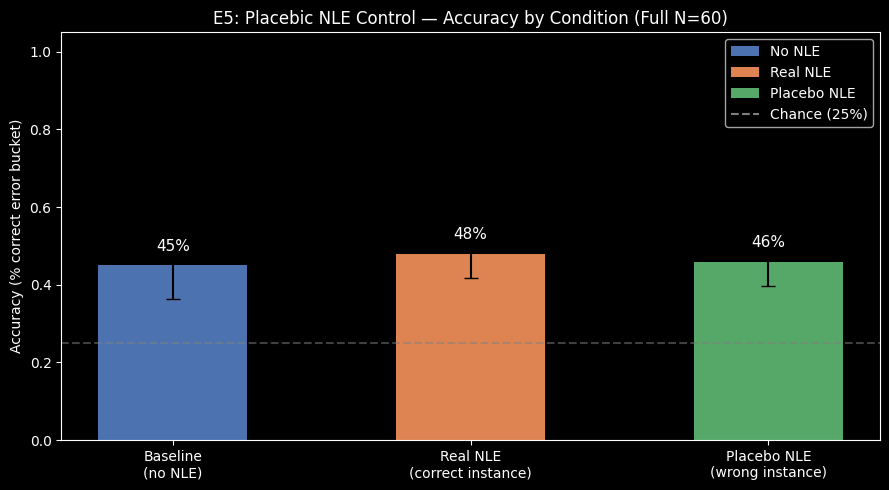

Figure saved: /home/fabian/Desktop/Second_XAI_Paper/Code/new_experiments/results/E5/full_accuracy_by_condition.png


In [10]:
cond_order = ['Baseline', 'Real_NLE', 'Placebo_NLE']
cond_labels = ['Baseline\n(no NLE)', 'Real NLE\n(correct instance)', 'Placebo NLE\n(wrong instance)']
colors = ['#4C72B0', '#DD8452', '#55A868']

accs = [acc.loc[c, 'accuracy'] if c in acc.index else 0 for c in cond_order]
lo = [acc.loc[c, 'ci_lo'] if c in acc.index else 0 for c in cond_order]
hi = [acc.loc[c, 'ci_hi'] if c in acc.index else 0 for c in cond_order]
errs = [[accs[i] - lo[i], hi[i] - accs[i]] for i in range(len(cond_order))]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(cond_labels, accs, color=colors, width=0.5,
              yerr=np.array(errs).T, capsize=5, ecolor='black')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy (% correct error bucket)')
mode_label = 'Pilot N=15' if PILOT_MODE else 'Full N=60'
ax.set_title(f'E5: Placebic NLE Control — Accuracy by Condition ({mode_label})')
ax.axhline(0.25, ls='--', color='gray', alpha=0.5, label='Chance (25%)')

for bar, a in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{a:.0%}', ha='center', va='bottom', fontsize=11)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='No NLE'),
    Patch(facecolor='#DD8452', label='Real NLE'),
    Patch(facecolor='#55A868', label='Placebo NLE'),
    plt.Line2D([0], [0], color='gray', ls='--', label='Chance (25%)')
]
ax.legend(handles=legend_elements)
plt.tight_layout()

fig_path = RESULTS_DIR / f'{"pilot" if PILOT_MODE else "full"}_accuracy_by_condition.png'
plt.savefig(fig_path, dpi=150)
plt.show()
print(f'Figure saved: {fig_path}')

## 9. Summary

In [11]:
# Save summary table
summary = acc.copy()
summary['ci'] = [f"[{row.ci_lo:.1%}, {row.ci_hi:.1%}]" for _, row in summary.iterrows()]
summary['has_nle'] = [c in ['Real_NLE', 'Placebo_NLE'] for c in summary.index]
summary.to_csv(RESULTS_DIR / f'{"pilot" if PILOT_MODE else "full"}_summary.csv')

print('=== E5 Summary ===')
print(summary[['accuracy', 'n_total', 'ci', 'has_nle']].round(3))
print()

# Interpretation
if all(c in acc.index for c in ['Baseline', 'Real_NLE', 'Placebo_NLE']):
    b = acc.loc['Baseline', 'accuracy']
    r = acc.loc['Real_NLE', 'accuracy']
    p = acc.loc['Placebo_NLE', 'accuracy']
    print('Interpretation:')
    if abs(r - p) < 0.05 and b > r + 0.05:
        print('  → Pattern: Baseline >> Real ≈ Placebo')
        print('  → Information overload: any extra text hurts, content irrelevant')
    elif b > r + 0.05 and r < p - 0.05:
        print('  → Pattern: Baseline >> Real, Placebo between')
        print('  → Real NLE actively misleads; generic text less harmful')
    elif abs(b - p) < 0.05 and b > r + 0.05:
        print('  → Pattern: Baseline ≈ Placebo >> Real')
        print('  → Real NLE uniquely misleads (content-specific harm)')
    elif abs(b - r) < 0.05 and abs(b - p) < 0.05:
        print('  → Pattern: All conditions similar')
        print('  → No NLE effect detected in this sample')
    else:
        print(f'  → Baseline={b:.1%}, Real={r:.1%}, Placebo={p:.1%}')
        print('  → Pattern unclear — inspect effect sizes and confidence data')

print()
if PILOT_MODE:
    print('NEXT: Review pilot results. If effect size is sufficient, set PILOT_MODE = False and re-run.')
else:
    print('Full experiment complete.')
    print(f'Results: {CACHE_PATH}')
    print(f'Summary: {RESULTS_DIR / "full_summary.csv"}')

=== E5 Summary ===
             accuracy  n_total              ci  has_nle
condition                                              
Baseline        0.450      120  [36.4%, 53.9%]    False
Placebo_NLE     0.458      240  [39.6%, 52.2%]     True
Real_NLE        0.479      240  [41.7%, 54.2%]     True

Interpretation:
  → Pattern: All conditions similar
  → No NLE effect detected in this sample

Full experiment complete.
Results: /home/fabian/Desktop/Second_XAI_Paper/Code/new_experiments/results/E5/full_results.csv
Summary: /home/fabian/Desktop/Second_XAI_Paper/Code/new_experiments/results/E5/full_summary.csv
